# Practical Statistics for Data Scientists (Python)
# Chapter 3. Statistial Experiments and Significance Testing
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

Import required Python packages.

In [1]:
%matplotlib inline

from pathlib import Path
import random

import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power

import matplotlib.pylab as plt

In [2]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

In [3]:
WEB_PAGE_DATA_CSV = DATA / 'web_page_data.csv'
FOUR_SESSIONS_CSV = DATA / 'four_sessions.csv'
CLICK_RATE_CSV = DATA / 'click_rates.csv'
IMANISHI_CSV = DATA / 'imanishi_data.csv'

# Resampling

In [4]:
session_times = pd.read_csv(WEB_PAGE_DATA_CSV)
session_times.Time = 100 * session_times.Time

In [16]:
session_times.head()

,Page,Time
0,Page A,21.0
1,Page B,253.0
2,Page A,35.0
3,Page B,71.0
4,Page A,67.0


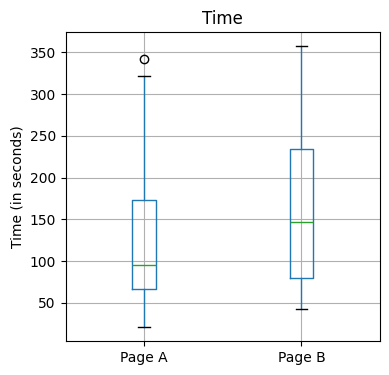

In [5]:
ax = session_times.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [10]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
print(mean_b - mean_a)

35.66666666666667


The following code is different to the R version. idx_A and idx_B are reversed.

In [11]:
# Permutation test example with stickiness
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()
    
nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]
print(perm_fun(session_times.Time, nA, nB))

6.523809523809518


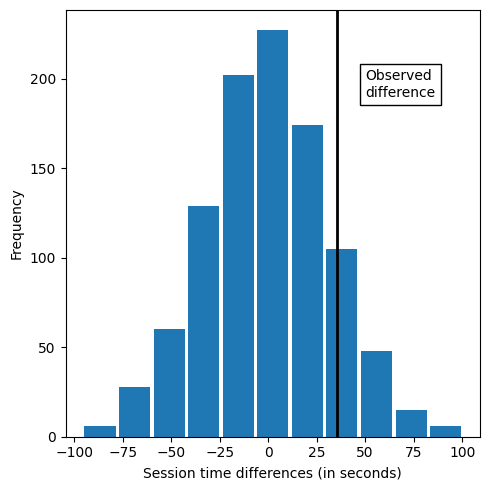

In [12]:
random.seed(1)
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x = mean_b - mean_a, color='black', lw=2)
ax.text(50, 190, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

This line calculates the proportion of permutations where the difference in means (perm_diffs) is greater than the observed difference (mean_b - mean_a).

In other words:
	•	perm_diffs > mean_b - mean_a produces a Boolean array — True for permutations where the permuted difference is greater than the observed difference.
	•	np.mean(...) converts this Boolean array to a fraction (since True = 1, False = 0).

So this value is effectively the p-value of a one-sided permutation test.

In [13]:
# convert perm_diffs to numpy array to avoid problems with some Python installations
perm_diffs = np.array(perm_diffs)
print(np.mean(perm_diffs > mean_b - mean_a))

0.121


<div class="wrap">

<h1>Permutation Test for A/B Session Time (Page A vs Page B)</h1>

<p class="small">Use this to test whether visitors’ <strong>average session time</strong> differs between Page A and Page B without assuming any specific distribution.</p>

<div class="note"><strong>Hypotheses</strong><br>
<strong>H₀ (null):</strong> A and B come from the same distribution (no true difference).<br>
<strong>H₁ (alt):</strong> There is a real difference (e.g., B &gt; A in mean session time).
</div>

<h2>1) Core Idea — “What if there were no real difference?”</h2>
<p>You observe a difference in means between B and A:</p>
<pre><code>observed_diff = mean(B) - mean(A)</code></pre>
<p>To judge if this is meaningful, simulate a world where <em>labels don’t matter</em> (i.e., A and B are exchangeable). If in that world, differences as big as <code>observed_diff</code> are rare, your observed effect is likely real.</p>

<h2>2) What Shuffling Means Under H₀</h2>
<ul>
  <li>Combine all session times into one pool.</li>
  <li>Randomly shuffle (permute) the values.</li>
  <li>Split back into two groups of the original sizes.</li>
</ul>
<p>Each shuffle is one sample from the <em>null world</em> where any difference arises purely from chance.</p>

<h2>3) Build the Null Distribution</h2>
<p>For each shuffle, compute the difference in means and store it. After many shuffles, you get the distribution of differences you’d expect by chance if H₀ were true.</p>

<pre><code class="language-python">import numpy as np

# Example arrays of session times (in seconds)
A = np.array([30, 45, 28, 35, 40])
B = np.array([42, 50, 38, 45, 48])

mean_a = A.mean()
mean_b = B.mean()
observed_diff = mean_b - mean_a

# Build null distribution via permutation
all_sessions = np.concatenate([A, B])
perm_diffs = []

rng = np.random.default_rng(0)  # fixed seed for reproducibility (optional)
for _ in range(10_000):         # number of permutations
    shuffled = rng.permutation(all_sessions)
    new_A = shuffled[:len(A)]
    new_B = shuffled[len(A):]
    perm_diffs.append(new_B.mean() - new_A.mean())

perm_diffs = np.array(perm_diffs)</code></pre>

<h2>4) Compare Observed to Null (Compute p-value)</h2>
<p>The p-value is the proportion of shuffled differences at least as extreme as your observed one.</p>

<pre><code class="language-python"># One-sided test: is B &gt; A?
p_value_one_sided = np.mean(perm_diffs &gt;= observed_diff)

# Two-sided test: is |B - A| != 0?
p_value_two_sided = np.mean(np.abs(perm_diffs) &gt;= abs(observed_diff))

print("Observed diff:", observed_diff)
print("One-sided p-value (B &gt; A):", p_value_one_sided)
print("Two-sided p-value:", p_value_two_sided)</code></pre>

<div class="note"><strong>Interpretation</strong><br>
If the p-value is small (e.g., &lt; 0.05), the observed difference would be unlikely under H₀. You reject H₀ and infer a real difference between A and B.</div>

<h2>5) Why This Works (Exchangeability)</h2>
<p>Under H₀, group labels are <em>exchangeable</em>: swapping “A” and “B” doesn’t change the joint data-generating process. Randomly reassigning labels therefore simulates the distribution of differences you’d expect purely by chance. The fraction of “as-extreme” outcomes is your empirical probability (p-value).</p>

<h2>6) Intuition Summary</h2>
<table>
  <thead>
    <tr><th>Step</th><th>What it Represents</th><th>Why It’s Logical</th></tr>
  </thead>
  <tbody>
    <tr>
      <td>Combine A and B</td>
      <td>Assume both samples come from the same distribution</td>
      <td>Models the null world (no true difference)</td>
    </tr>
    <tr>
      <td>Shuffle repeatedly</td>
      <td>Simulate random assignment</td>
      <td>Generates differences due to chance alone</td>
    </tr>
    <tr>
      <td>Compute diff each time</td>
      <td>Null distribution of mean differences</td>
      <td>Shows what “random differences” look like</td>
    </tr>
    <tr>
      <td>Compare to observed</td>
      <td>Empirical p-value</td>
      <td>How rare is the real effect under H₀?</td>
    </tr>
  </tbody>
</table>

<h2>7) Practical Notes</h2>
<ul>
  <li><span class="tag">Non-parametric</span> — No normality or equal-variance assumptions needed.</li>
  <li><span class="tag">Flexible</span> — Works with means, medians, percentiles, or other metrics.</li>
  <li><span class="tag">Reproducibility</span> — Set a random seed if you need stable results during demos.</li>
  <li><span class="tag">Two-sided vs One-sided</span> — Choose based on your hypothesis (directional or not).</li>
</ul>

</div>

# Statistical Significance and P-Values

Observed difference: 0.0368%


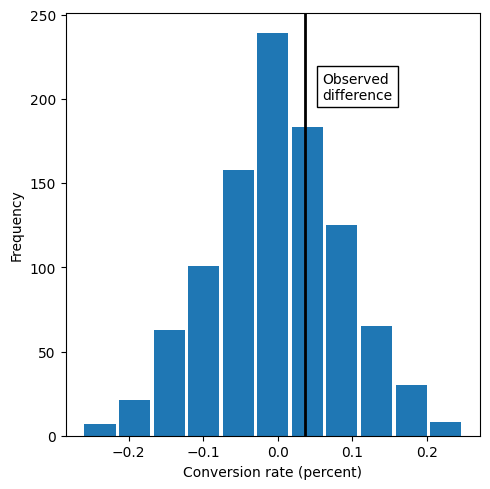

In [14]:
random.seed(1)
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Observed difference: {obs_pct_diff:.4f}%')
conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

perm_diffs = [100 * perm_fun(conversion, 23739, 22588) 
              for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## P-Value
If `np.mean` is applied to a list of booleans, it gives the percentage of how often True was found in the list (#True / #Total).

In [15]:
print(np.mean([diff > obs_pct_diff for diff in perm_diffs]))

0.332


In [7]:
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)

print(f'p-value for single sided test: {p_value / 2:.4f}')

p-value for single sided test: 0.3498


# t-Tests

In [17]:
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time, 
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False)
print(f'p-value for single sided test: {res.pvalue / 2:.4f}')

p-value for single sided test: 0.1408


In [14]:
tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times.Page == 'Page A'].Time, 
    session_times[session_times.Page == 'Page B'].Time,
    usevar='unequal', alternative='smaller')
print(f'p-value: {pvalue:.4f}')

p-value: 0.1408


That’s an insightful question — both t-tests and permutation tests are used to compare group means, but they differ in assumptions, computational cost, and use cases. Here’s why t-tests are often preferred in practice, even though permutation tests can be more general.

⸻

⚖️ 1. Assumptions

t-test
	•	Assumes the data come from normally distributed populations.
	•	Assumes independent samples.
	•	Can handle unequal variances (Welch’s t-test).
	•	It’s a parametric test (relies on mathematical assumptions).

If those assumptions are roughly true, the t-test is very efficient — it gives accurate results even with small sample sizes.

⸻

Permutation test
	•	Makes no distributional assumptions.
	•	It’s a non-parametric test — purely data-driven.
	•	It builds a sampling distribution of the test statistic (e.g., mean difference) by repeatedly shuffling the group labels.

This is conceptually simple and robust, but computationally heavier.

⸻

🏃 2. Speed and Efficiency
	•	The t-test uses a mathematical formula — instant and exact.
	•	The permutation test must simulate thousands (or millions) of label shuffles — slow if data are large.

# ANOVA

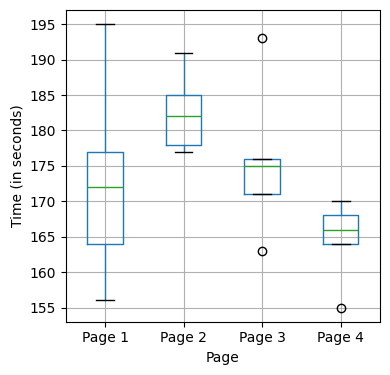

In [18]:
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)

ax = four_sessions.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('Page')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.title('')

plt.tight_layout()
plt.show()

In [19]:
print(pd.read_csv(FOUR_SESSIONS_CSV).head())

     Page  Time
0  Page 1   164
1  Page 2   178
2  Page 3   175
3  Page 4   155
4  Page 1   172


In [25]:
observed_variance = four_sessions.groupby('Page').mean().var().iloc[0]
print(four_sessions.groupby('Page').mean())
print('Observed means:', four_sessions.groupby('Page').mean().values.ravel())
print('Variance:', observed_variance)
# Permutation test example with stickiness
def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var().iloc[0]
    
print(perm_test(four_sessions))

         Time
Page         
Page 1  172.8
Page 2  182.6
Page 3  175.6
Page 4  164.6
Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655
60.119999999999955


Pr(Prob) 0.07633333333333334


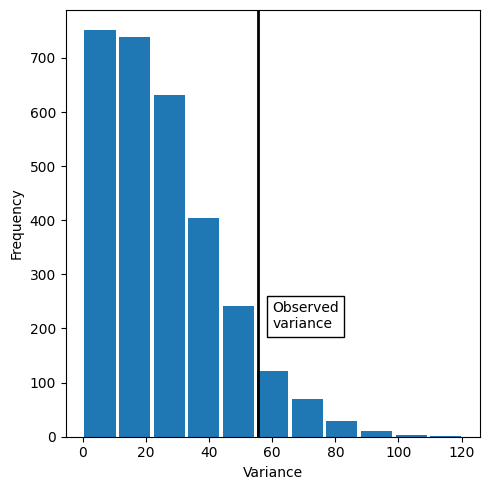

In [18]:
random.seed(1)
perm_variance = [perm_test(four_sessions) for _ in range(3000)]
print('Pr(Prob)', np.mean([var > observed_variance for var in perm_variance]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x = observed_variance, color='black', lw=2)
ax.text(60, 200, 'Observed\nvariance', bbox={'facecolor':'white'})
ax.set_xlabel('Variance')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## F-Statistic
We can compute an ANOVA table using statsmodel.

In [19]:
model = smf.ols('Time ~ Page', data=four_sessions).fit()
                
aov_table = sm.stats.anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN


In [20]:
res = stats.f_oneway(four_sessions[four_sessions.Page == 'Page 1'].Time, 
                     four_sessions[four_sessions.Page == 'Page 2'].Time,
                     four_sessions[four_sessions.Page == 'Page 3'].Time,
                     four_sessions[four_sessions.Page == 'Page 4'].Time)
print(f'F-Statistic: {res.statistic / 2:.4f}')
print(f'p-value: {res.pvalue / 2:.4f}')

F-Statistic: 1.3699
p-value: 0.0388


### Two-way anova only available with statsmodels
```
formula = 'len ~ C(supp) + C(dose) + C(supp):C(dose)'
model = ols(formula, data).fit()
aov_table = anova_lm(model, typ=2)
```

<h3>One way anova</h3>

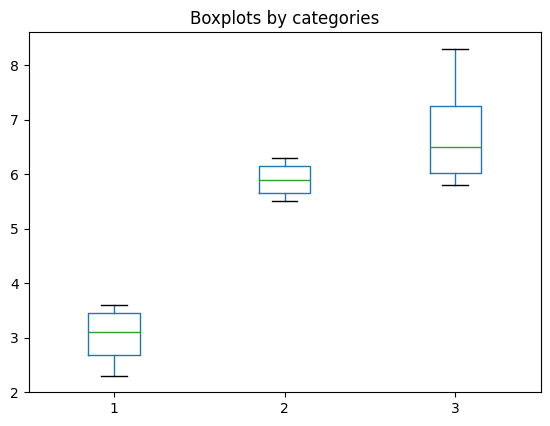

In [29]:
y = np.array([2.8, 3.6, 3.4, 2.3,
5.5, 6.3, 6.1, 5.7,
5.8, 8.3, 6.9, 6.1])
treatm = pd.Categorical([1, 1, 1, 1,
2, 2, 2, 2,
3, 3, 3, 3])
D = pd.DataFrame({'y': y, 'treatm': treatm})
n = len(D)
k = len(np.unique(D['treatm']))
ni = n // k if n % k == 0 else None # replicates per treatment assuming equal group sizes

D.boxplot(by='treatm', grid=False)
plt.title('Boxplots by categories')
plt.suptitle('') # Removing automatic titles
plt.xlabel('')
plt.show()

In [33]:
mu = np.mean(y)
muis = D.groupby("treatm",observed=True)["y"].mean()
alpha = muis - mu
print(mu)
print(muis)
print(alpha)

5.233333333333333
treatm
1    3.025
2    5.900
3    6.775
Name: y, dtype: float64
treatm
1   -2.208333
2    0.666667
3    1.541667
Name: y, dtype: float64


So our estimate of the overall mean is ˆ
µ= 5.23, and the group levels (offsets from
the overall sample mean) are ˆ
α1 =−2.21, ˆ
α2 = 0.67 and ˆ
α3 = 1.54. The question we
need to answer is: how likely is it that the observed differences in group means are
random variation? If this is very unlikely, then it can be concluded that at least one
of them is significantly different from zero.

# Chi-Square Test
## Chi-Square Test: A Resampling Approach

In [34]:
# Table 3-4
click_rate = pd.read_csv(CLICK_RATE_CSV)
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
print(clicks)

Headline  Headline A  Headline B  Headline C
Click                                       
Click             14           8          12
No-click         986         992         988


In [35]:
# Table 3-5
row_average = clicks.mean(axis=1)
pd.DataFrame({
    'Headline A': row_average,
    'Headline B': row_average,
    'Headline C': row_average,
})

,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


In [23]:
# Resampling approach
box = [1] * 34
box.extend([0] * 2966)
random.shuffle(box)

def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append([(observe - expect) ** 2 / expect
                                  for observe in row])
    # return sum of squares
    return np.sum(pearson_residuals)

expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [expected_clicks, expected_noclicks]
chi2observed = chi2(clicks.values, expected)

def perm_fun(box):
    random.shuffle(box)
    sample_clicks = [sum(box[0:1000]),
                     sum(box[1000:2000]),
                     sum(box[2000:3000])]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [perm_fun(box) for _ in range(2000)]

resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4660


In [24]:
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chisq:.4f}')
print(f'p-value: {pvalue:.4f}')

Observed chi2: 1.6659
p-value: 0.4348


The above algorithm uses sampling into the three sets without replacement. Alternatively, it is also possible to sample with replacement.

In [25]:
expected = [expected_clicks, expected_noclicks]
def sample_with_replacement(box):
    sample_clicks = [sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [sample_with_replacement(box) for _ in range(2000)]

resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4845


## Figure chi-sq distribution

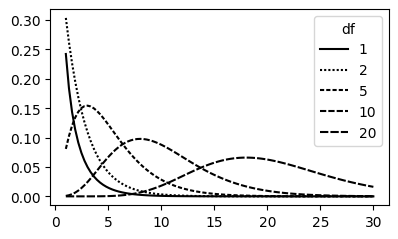

In [26]:
x = [1 + i * (30 - 1) / 99 for i in range(100)]

chi = pd.DataFrame({
    'x': x,
    'chi_1': stats.chi2.pdf(x, df=1),
    'chi_2': stats.chi2.pdf(x, df=2),
    'chi_5': stats.chi2.pdf(x, df=5),
    'chi_10': stats.chi2.pdf(x, df=10),
    'chi_20': stats.chi2.pdf(x, df=20),
})
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(chi.x, chi.chi_1, color='black', linestyle='-', label='1')
ax.plot(chi.x, chi.chi_2, color='black', linestyle=(0, (1, 1)), label='2')
ax.plot(chi.x, chi.chi_5, color='black', linestyle=(0, (2, 1)), label='5')
ax.plot(chi.x, chi.chi_10, color='black', linestyle=(0, (3, 1)), label='10')
ax.plot(chi.x, chi.chi_20, color='black', linestyle=(0, (4, 1)), label='20')
ax.legend(title='df')

plt.tight_layout()
plt.show()

## Fisher's Exact Test
Scipy has only an implementation of Fisher's Exact test for 2x2 matrices. There is a github repository that provides a Python implementation that uses the same code as the R version. Installing this requires a Fortran compiler. 
```
stats.fisher_exact(clicks)
```

In [27]:
# stats.fisher_exact(clicks.values)

### Scientific Fraud

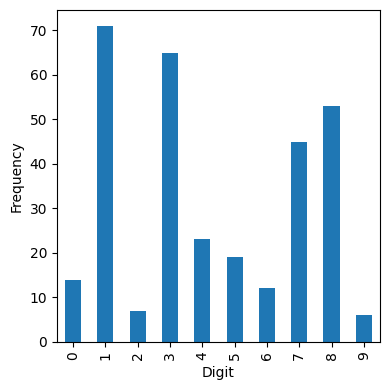

In [28]:
imanishi = pd.read_csv(IMANISHI_CSV)
imanishi.columns = [c.strip() for c in imanishi.columns]
ax = imanishi.plot.bar(x='Digit', y=['Frequency'], legend=False,
                      figsize=(4, 4))
ax.set_xlabel('Digit')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Power and Sample Size
statsmodels has a number of methods for power calculation

see e.g.: https://machinelearningmastery.com/statistical-power-and-power-analysis-in-python/

In [29]:
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, 
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 116602.393


In [30]:
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, 
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 5488.408
